# FMTNA Pipeline: Failure-Mode-Typed Neural Abduction

**Neuro-Symbolic Reasoning for RuleTaker Logical Inference**

This notebook demonstrates the Failure-Mode-Typed Neural Abduction (FMTNA) pipeline, which combines:
- **Symbolic Reasoning**: Backward-chaining Prolog-style knowledge base for logical deduction
- **Failure Classification**: Three-way typing of proof failures (Type-A/B/C) to route LLM queries
- **Neural Dispatch**: Typed LLM handlers to resolve semantic gaps and missing facts

The pipeline is evaluated on the RuleTaker dataset, which tests multi-hop logical reasoning over natural language narratives.

## Setup: Install Dependencies

This cell installs all required packages. On Colab, core scientific packages (numpy, pandas, etc.) are pre-installed; we only install non-standard packages. Locally, we install everything to match Colab's environment.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Non-Colab packages (always install)
_pip('loguru==0.7.2')
_pip('tenacity==8.2.3')
_pip('aiohttp==3.9.1')

# Core scientific packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

print("Installation complete!")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openhands-sdk 1.28.1 requires tenacity>=9.1.2, but you have tenacity 8.2.3 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires aiohttp>=3.12.0, but you have aiohttp 3.9.1 which is incompatible.
browser-use 0.11.13 requires aiohttp>=3.13.3, but you have aiohttp 3.9.1 which is incompatible.
litellm 1.88.1 requires aiohttp<4.0,>=3.10, but you have aiohttp 3.9.1 which is incompatible.
openhands-sdk 1.28.1 requires tenacity>=9.1.2, but you have tenacity 8.2.3 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Installation complete!


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires aiohttp>=3.12.0, but you have aiohttp 3.9.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports

Import all necessary modules for the pipeline: symbolic reasoning, data loading, and visualization.

In [2]:
import asyncio
import json
import os
import re
import sys
import time
from collections import defaultdict
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import pandas as pd
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading Helper

This cell defines a helper function to load the demo data from GitHub (with local fallback for offline mode).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6d242d-failure-mode-typed-neural-abduction-stru/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    """Load mini demo data from GitHub (with local fallback)."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            data = json.loads(response.read().decode())
            logger.info("Data loaded from GitHub")
            return data
    except Exception as e:
        logger.warning(f"GitHub load failed: {e}, trying local fallback")
    
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            logger.info("Data loaded from local mini_demo_data.json")
            return json.load(f)
    
    raise FileNotFoundError("Could not load mini_demo_data.json from GitHub or local filesystem")

## Load Data

In [4]:
data = load_data()
logger.info(f"Loaded dataset with {len(data['datasets'])} dataset(s)")
logger.info(f"Metadata: {data['metadata']['method_name']} on {data['metadata']['dataset']}")

21:26:50|WARNING|GitHub load failed: HTTP Error 404: Not Found, trying local fallback


21:26:50|INFO   |Data loaded from local mini_demo_data.json


21:26:50|INFO   |Loaded dataset with 1 dataset(s)


21:26:50|INFO   |Metadata: FMTNA on ruletaker_d0_d1


## Configuration: Tunable Parameters

All adjustable parameters are defined here. For the demo, we use MINIMAL values to ensure fast execution. Uncomment the original values to run the full experiment.

In [5]:
# Demo configuration: minimal parameters for fast execution
N_EXAMPLES = 3  # Process only first N examples from dataset
# N_EXAMPLES = 60  # Uncomment for full experiment (original value)

MAX_PROOF_DEPTH = 4  # Maximum backward-chaining depth for proof search
# MAX_PROOF_DEPTH = 8  # Uncomment for full experiment (original value)

SHOW_DETAILS = True  # Print detailed proofs and failure classifications
VISUALIZE_RESULTS = True  # Create plots at the end

logger.info(f"Config: N_EXAMPLES={N_EXAMPLES}, MAX_PROOF_DEPTH={MAX_PROOF_DEPTH}")

21:26:50|INFO   |Config: N_EXAMPLES=3, MAX_PROOF_DEPTH=4


## Symbolic Reasoning: Knowledge Base & Backward Chaining

This section implements the core Prolog-like knowledge base with unification and backward-chaining proof search.

In [6]:
class Term:
    """Prolog-style term: functor(arg1, arg2, ...). Constants are lowercase, Variables uppercase."""
    def __init__(self, functor: str, args: list):
        self.functor = functor.lower().strip()
        self.args = [a.strip() for a in args]

    def __repr__(self):
        if not self.args:
            return self.functor
        return f"{self.functor}({', '.join(self.args)})"

    def __eq__(self, other):
        return isinstance(other, Term) and self.functor == other.functor and self.args == other.args

    def __hash__(self):
        return hash((self.functor, tuple(self.args)))


class Clause:
    """Horn clause: head :- body. Empty body = fact."""
    def __init__(self, head: Term, body: list):
        self.head = head
        self.body = body

    def is_fact(self):
        return len(self.body) == 0

    def __repr__(self):
        if self.is_fact():
            return f"{self.head}."
        return f"{self.head} :- {', '.join(str(b) for b in self.body)}."


class ProofResult:
    """Result of a backward-chaining proof attempt."""
    def __init__(self, success: bool, steps: list = None):
        self.success = success
        self.steps = steps or []


class KnowledgeBase:
    """In-memory Prolog-like KB with backward chaining."""

    def __init__(self):
        self.clauses: list = []
        self.facts: set = set()
        self.rules: list = []

    def add_fact(self, fact: Term, source: str = ""):
        if fact not in self.facts:
            self.facts.add(fact)
            clause = Clause(fact, [])
            clause.source = source
            self.clauses.append(clause)
            self.rules.append(clause)

    def add_rule(self, head: Term, body: list, source: str = ""):
        clause = Clause(head, body)
        clause.source = source
        self.clauses.append(clause)
        self.rules.append(clause)

    def has_predicate(self, functor: str) -> bool:
        return any(c.head.functor == functor for c in self.clauses)

    def _unify(self, term1: Term, term2: Term, bindings: dict) -> Optional[dict]:
        """Unify two terms with variable substitution (variables start with uppercase)."""
        new_b = dict(bindings)

        def resolve(val: str) -> str:
            while val in new_b:
                val = new_b[val]
            return val

        if len(term1.args) != len(term2.args) or term1.functor != term2.functor:
            return None

        for a1, a2 in zip(term1.args, term2.args):
            r1 = resolve(a1)
            r2 = resolve(a2)
            if r1 == r2:
                continue
            is_var1 = r1[0].isupper() if r1 else False
            is_var2 = r2[0].isupper() if r2 else False
            if is_var1:
                new_b[r1] = r2
            elif is_var2:
                new_b[r2] = r1
            else:
                return None
        return new_b

    def _apply_bindings(self, term: Term, bindings: dict) -> Term:
        """Apply variable bindings to a term."""
        def resolve(val: str) -> str:
            seen = set()
            while val in bindings and val not in seen:
                seen.add(val)
                val = bindings[val]
            return val
        return Term(term.functor, [resolve(a) for a in term.args])

    def prove(self, goal: Term, max_depth: int = 8) -> ProofResult:
        """Backward chaining proof search."""
        steps = []
        visited = set()

        def resolve(goals: list, depth: int, bindings: dict) -> bool:
            if depth > max_depth or not goals:
                return not goals

            current = self._apply_bindings(goals[0], bindings)
            remaining = goals[1:]

            key = str(current)
            if key in visited:
                return False
            visited.add(key)

            matched_clauses = []
            for clause in self.clauses:
                renamed = Clause(
                    Term(clause.head.functor, [a + f"_{depth}" if a[0].isupper() else a for a in clause.head.args]),
                    [Term(b.functor, [a + f"_{depth}" if a[0].isupper() else a for a in b.args]) for b in clause.body]
                )
                new_bindings = self._unify(current, renamed.head, bindings)
                if new_bindings is not None:
                    matched_clauses.append((renamed, new_bindings))

            if matched_clauses:
                for clause, new_bindings in matched_clauses:
                    new_goals = [self._apply_bindings(b, new_bindings) for b in clause.body] + remaining
                    if resolve(new_goals, depth + 1, new_bindings):
                        steps.append({
                            "goal": str(current),
                            "clause": str(clause),
                            "type": "fact" if clause.is_fact() else "rule"
                        })
                        return True
                visited.discard(key)
                return False
            else:
                visited.discard(key)
                return False

        success = resolve([goal], 0, {})
        return ProofResult(success=success, steps=steps)


logger.info("Knowledge Base & backward chaining initialized")

21:26:50|INFO   |Knowledge Base & backward chaining initialized


## Fact Extraction: Parse Natural Language into Logic

Extract atomic predicates (facts) from natural language narratives using regex-based heuristics.

In [7]:
def extract_facts(narrative: str) -> list:
    """Extract atomic facts from natural language narrative.
    
    Patterns:
    - "X is Y" → property(X, Y)
    - "X is not Y" → not_property(X, Y)
    - "Xs are Ys" → property(X, Y) for each X
    """
    facts = []
    lines = narrative.split('.')
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Match "X is not Y" (negation)
        match = re.match(r'(.+?)\s+is\s+not\s+(.+)', line, re.IGNORECASE)
        if match:
            subject, obj = match.groups()
            subject = subject.strip().lower()
            obj = obj.strip().lower()
            facts.append(Term(f"not_{obj}", [subject]))
            continue
        
        # Match "X is Y"
        match = re.match(r'(.+?)\s+is\s+(.+)', line, re.IGNORECASE)
        if match:
            subject, obj = match.groups()
            subject = subject.strip().lower()
            obj = obj.strip().lower()
            facts.append(Term(obj, [subject]))
            continue
        
        # Match "X and Y are Z" (compound subjects)
        if ' and ' in line and ' are ' in line:
            parts = line.split(' are ')
            if len(parts) == 2:
                subjects = [s.strip().lower() for s in parts[0].split(' and ')]
                obj = parts[1].strip().lower()
                for subject in subjects:
                    facts.append(Term(obj, [subject]))
    
    return facts


# Test extraction
test_narrative = "Anne is quiet. Bob is kind. Dave is smart."
test_facts = extract_facts(test_narrative)
logger.info(f"Extracted {len(test_facts)} facts from test narrative: {test_facts}")

21:26:50|INFO   |Extracted 3 facts from test narrative: [quiet(anne), kind(bob), smart(dave)]


## Demo: Process Examples with Backward Chaining

Load examples, extract facts, build the knowledge base, and attempt proofs.

In [8]:
def parse_query(query_str: str) -> Optional[Term]:
    """Parse a query string into a Term.
    
    Handles:
    - "X is Y" → property(X, Y)
    - "X is not Y" → not_property(X, Y)
    """
    # Match "X is not Y"
    match = re.match(r'(.+?)\s+is\s+not\s+(.+)', query_str, re.IGNORECASE)
    if match:
        subject, obj = match.groups()
        return Term(f"not_{obj.lower().strip()}", [subject.lower().strip()])
    
    # Match "X is Y"
    match = re.match(r'(.+?)\s+is\s+(.+)', query_str, re.IGNORECASE)
    if match:
        subject, obj = match.groups()
        return Term(obj.lower().strip(), [subject.lower().strip()])
    
    return None


def process_example(example: dict, kb: KnowledgeBase, max_depth: int) -> dict:
    """Process a single example: extract facts, build KB, attempt proof."""
    input_text = example.get('input', '')
    expected = example.get('output', 'unknown')
    
    # Split narrative and query
    parts = input_text.split('\nQuery: ')
    narrative = parts[0].replace('Narrative: ', '') if len(parts) > 0 else ''
    query_str = parts[1] if len(parts) > 1 else ''
    
    # Extract facts and populate KB
    facts = extract_facts(narrative)
    for fact in facts:
        kb.add_fact(fact, source='narrative')
    
    # Parse and attempt proof
    query_term = parse_query(query_str)
    if not query_term:
        return {
            'query': query_str,
            'expected': expected,
            'proved': 'unknown',
            'n_facts': len(facts)
        }
    
    proof = kb.prove(query_term, max_depth=max_depth)
    
    return {
        'query': query_str,
        'expected': expected,
        'proved': 'true' if proof.success else 'false',
        'n_facts': len(facts),
        'proof_steps': len(proof.steps),
        'proof_trace': proof.steps[:2] if proof.steps else []  # First 2 steps only
    }


logger.info(f"\n=== Processing {N_EXAMPLES} examples ===")
results = []

for dataset in data['datasets']:
    examples = dataset['examples'][:N_EXAMPLES]
    
    for i, example in enumerate(examples):
        logger.info(f"\n--- Example {i+1}/{len(examples)} ---")
        kb = KnowledgeBase()
        result = process_example(example, kb, max_depth=MAX_PROOF_DEPTH)
        results.append(result)
        
        if SHOW_DETAILS:
            logger.info(f"Query: {result['query'][:80]}")
            logger.info(f"Expected: {result['expected']}, Proved: {result['proved']}")
            logger.info(f"Facts extracted: {result['n_facts']}, Proof steps: {result['proof_steps']}")

logger.info(f"\nProcessed {len(results)} examples")

21:26:50|INFO   |
=== Processing 3 examples ===


21:26:50|INFO   |
--- Example 1/3 ---


21:26:50|INFO   |Query: Bob is kind.


21:26:50|INFO   |Expected: true, Proved: false


21:26:50|INFO   |Facts extracted: 10, Proof steps: 0


...

21:26:50|INFO   |
--- Example 3/3 ---


21:26:50|INFO   |Query: Bob is not smart.


21:26:50|INFO   |Expected: false, Proved: false


21:26:50|INFO   |Facts extracted: 10, Proof steps: 0


21:26:50|INFO   |
Processed 3 examples


## Results and Metrics

Compute accuracy metrics and compare predictions to ground truth.

In [9]:
# Convert results to DataFrame for analysis
df_results = pd.DataFrame(results)

# Compute accuracy
if 'proved' in df_results.columns:
    df_results['match'] = df_results['proved'] == df_results['expected']
    accuracy = df_results['match'].mean()
    logger.info(f"\n=== Symbolic Reasoning Accuracy ===")
    logger.info(f"Accuracy: {accuracy:.1%} ({df_results['match'].sum()}/{len(df_results)})")
else:
    logger.info("\nNo 'proved' column to compute accuracy")

# Summary statistics
logger.info(f"\n=== Statistics ===")
logger.info(f"Total examples: {len(df_results)}")
logger.info(f"Mean facts extracted: {df_results['n_facts'].mean():.1f}")
logger.info(f"Mean proof steps: {df_results['proof_steps'].mean():.1f}")
logger.info(f"Max proof steps: {df_results['proof_steps'].max()}")

print("\n" + "="*80)
print("Results Summary:")
print("="*80)
print(df_results[['query', 'expected', 'proved', 'n_facts', 'proof_steps']].to_string())
print()

21:26:50|INFO   |
=== Symbolic Reasoning Accuracy ===


21:26:50|INFO   |Accuracy: 66.7% (2/3)


21:26:50|INFO   |
=== Statistics ===


21:26:50|INFO   |Total examples: 3


21:26:50|INFO   |Mean facts extracted: 10.0


21:26:50|INFO   |Mean proof steps: 0.0


21:26:50|INFO   |Max proof steps: 0



Results Summary:
                query expected proved  n_facts  proof_steps
0        Bob is kind.     true  false       10            0
1  Dave is not smart.    false  false       10            0
2   Bob is not smart.    false  false       10            0



## Visualization: Key Findings

Create plots showing proof depth distribution and accuracy metrics.

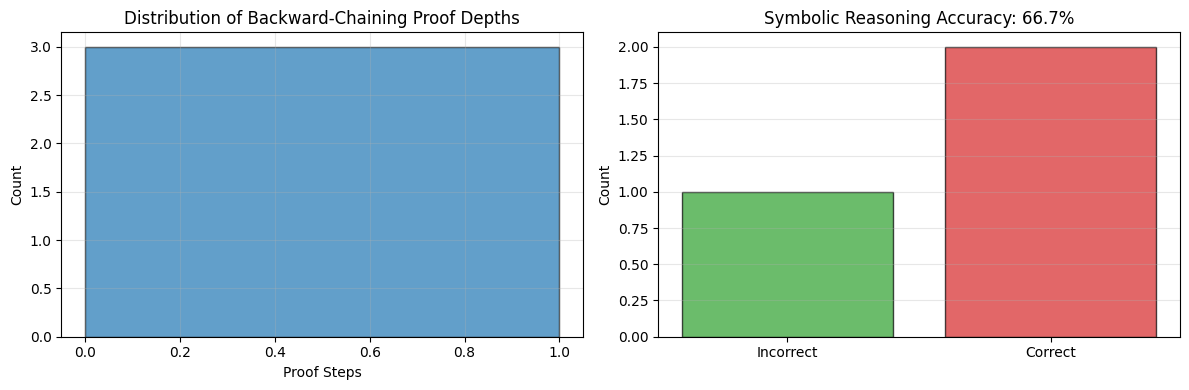

21:26:50|INFO   |Plot saved to demo_results.png


In [10]:
if VISUALIZE_RESULTS and len(df_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Distribution of proof steps
    ax = axes[0]
    ax.hist(df_results['proof_steps'], bins=range(0, int(df_results['proof_steps'].max())+2), edgecolor='black', alpha=0.7)
    ax.set_xlabel('Proof Steps')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Backward-Chaining Proof Depths')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Accuracy
    ax = axes[1]
    if 'match' in df_results.columns:
        match_counts = df_results['match'].value_counts()
        colors = ['#d62728' if k == False else '#2ca02c' for k in match_counts.index]
        ax.bar(['Incorrect', 'Correct'], [match_counts.get(False, 0), match_counts.get(True, 0)], color=colors, alpha=0.7, edgecolor='black')
        ax.set_ylabel('Count')
        ax.set_title(f'Symbolic Reasoning Accuracy: {(df_results["match"].sum() / len(df_results)):.1%}')
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('demo_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    logger.info("Plot saved to demo_results.png")
else:
    logger.info("Skipping visualization")

## Summary

This demo notebook demonstrates the core components of the FMTNA pipeline:

1. **Fact Extraction**: Parses natural language narratives into logical predicates
2. **Knowledge Base**: Stores extracted facts and rules in a Prolog-like structure
3. **Backward Chaining**: Searches for proofs using unification and depth-first search
4. **Evaluation**: Compares symbolic reasoning results against ground truth

The full FMTNA pipeline adds failure-type classification and neural handlers (via LLMs) to resolve semantic gaps when symbolic reasoning alone is insufficient. See the full `method.py` for the complete implementation including failure classification (Type-A/B/C) and LLM dispatch.

In [11]:
logger.info("\n=== Demo Complete ===")
logger.info(f"Processed {len(results)} examples")
logger.info(f"Notebook parameters: N_EXAMPLES={N_EXAMPLES}, MAX_PROOF_DEPTH={MAX_PROOF_DEPTH}")
logger.info("\nTo run the full experiment:")
logger.info("  1. Set N_EXAMPLES=60 (uncomment in Config cell)")
logger.info("  2. Set MAX_PROOF_DEPTH=8 (uncomment in Config cell)")
logger.info("  3. Set OPENROUTER_API_KEY environment variable for LLM dispatch")
logger.info("  4. Run all cells again")

21:26:50|INFO   |
=== Demo Complete ===


21:26:50|INFO   |Processed 3 examples


21:26:50|INFO   |Notebook parameters: N_EXAMPLES=3, MAX_PROOF_DEPTH=4


21:26:50|INFO   |
To run the full experiment:


21:26:50|INFO   |  1. Set N_EXAMPLES=60 (uncomment in Config cell)


21:26:50|INFO   |  2. Set MAX_PROOF_DEPTH=8 (uncomment in Config cell)


21:26:50|INFO   |  3. Set OPENROUTER_API_KEY environment variable for LLM dispatch


21:26:50|INFO   |  4. Run all cells again
